In [2]:
import os
import importlib
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
import torch

import util
import peripheral

importlib.reload(util)
importlib.reload(peripheral)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

In [3]:
"""
Typical configuration for a normal hearing auditory nerve model.

The `config_random_slice` section has been commented out. This section
is relevant for fixed-length stimuli where the final nervegram should
be excerpted from a longer nervegram with some temporal jitter.
"""
config_peripheral_model = {
    "config_anf_rate_level": {
        "compression_power": 0.3,
        "compression_power_default": 0.3,
        "dynamic_range": [
            20.0,
            40.0,
            80.0
        ],
        "dynamic_range_interval": 0.95,
        "envelope_mode": True,
        "rate_max": [
            250.0,
            250.0,
            100.0
        ],
        "rate_spont": [
            70.0,
            4.0,
            0.1
        ],
        "threshold": [
            0.0,
            12.0,
            28.0
        ]
    },
    "config_anf_spike_generator": {
        "mode": "approx",
        "n_per_channel": [
            384,
            160,
            96
        ]
    },
    "config_cochlear_filterbank": {
        "bw_mult": 1.0,
        "cfs": {
            "num": 50,
            "start": 60.0,
            "stop": 16000.0
        },
        "fir_dur": 0.05,
        "order": 4,
        "type": "gammatone_filterbank_fir"
    },
    "config_ihc_lowpass_filter": {
        "cutoff": 3000,
        "fir_dur": 0.05,
        "order": 7
    },
    "config_ihc_transduction": {
        "rectify": True
    },
    "config_middle_ear_filter": {
        "minimum_phase": True,
        "mode": "iso226_2003",
        "numtaps": 1025
    },
    "config_random_slice": {
        # "buffer": [
        #     0,
        #     500
        # ],
        # "size": [
        #     50,
        #     20000
        # ]
    },
    "sr_input": 50000.0,
    "sr_output": 10000.0
}


In [4]:
"""
Construct the PyTorch model and assign it to the GPU (if available)
"""
model = peripheral.Model(**config_peripheral_model)
model.to(device)


Model(
  (body): Sequential(
    (middle_ear_filter): MiddleEarFilter()
    (cochlear_filterbank): GammatoneFilterbank()
    (ihc_transduction): IHCTransduction()
    (ihc_lowpass_filter): IHCLowpassFilter()
    (anf_rate_level): SigmoidRateLevelFunction(
      (envelope_function): HilbertEnvelope(
        (hilbert): Hilbert()
      )
    )
    (anf_spike_generator): BinomialSpikeGenerator()
  )
  (head): Identity()
)

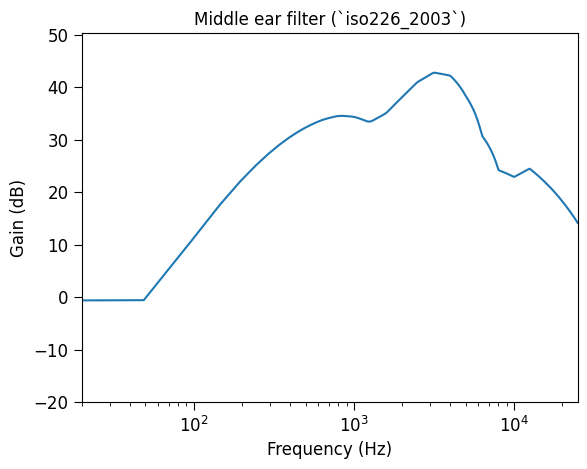

In [5]:
"""
Visualize the middle ear filter's frequency response.
"""
sr = model.sr_input
fir = model.body.middle_ear_filter.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="Middle ear filter (`iso226_2003`)",
)
plt.show()


/rdma/vast-rdma/vast/mcdermott/msaddler/peripheral_model/util.py:171: RuntimeWarning: divide by zero encountered in log10
  pxx = 10.0 * np.log10(pxx / np.square(p_ref))


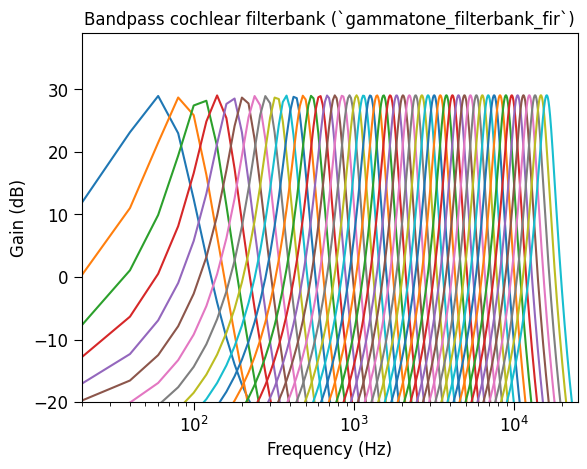

In [6]:
"""
Visualize the cochlear filterbank's frequency response.
"""
sr = model.sr_input
fir = model.body.cochlear_filterbank.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx.T)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="Bandpass cochlear filterbank (`gammatone_filterbank_fir`)",
)
plt.show()


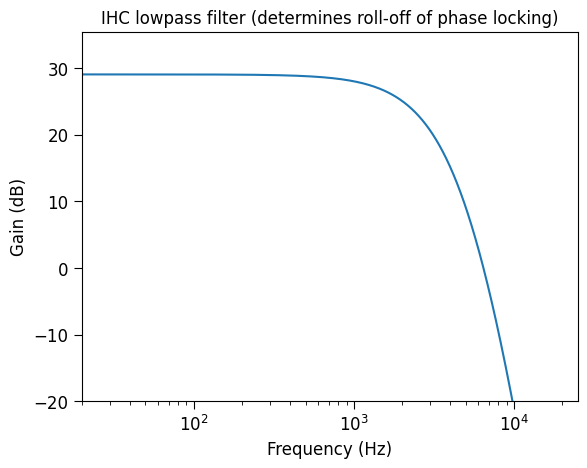

In [7]:
"""
Visualize the IHC lowpass filter's frequency response.
"""
sr = model.sr_input
fir = model.body.ihc_lowpass_filter.fir.detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = util.periodogram(fir, sr)
ax.plot(fxx, pxx)
util.format_axes(
    ax,
    xscale="log",
    xlimits=[20, sr / 2],
    ylimits=[-20, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Gain (dB)",
    str_title="IHC lowpass filter (determines roll-off of phase locking)",
)
plt.show()


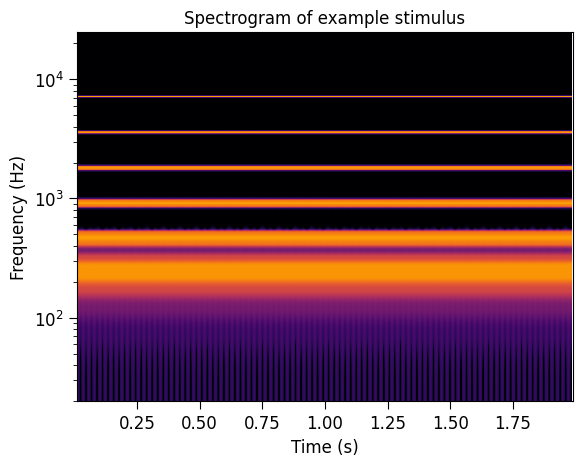

In [8]:
"""
Generate an example stimulus.
"""
sr = model.sr_input

t = np.arange(0, 2, 1 / sr)
x = np.zeros_like(t)
f0 = 220
for h in [1, 2, 4, 8, 16, 32]:
    f = h * f0
    x += np.sin(2 * np.pi * f * t)
x = util.set_dbspl(x, 60.0)

ipd.display(ipd.Audio(rate=sr, data=x))

fig, ax = plt.subplots()
nfft = 1024
kwargs_specgram = {
    "NFFT": nfft,
    "Fs": sr,
    "mode": "magnitude",
    "scale": "dB",
    "cmap": "inferno",
    "noverlap": int(0.9 * nfft),
    "clim": [-100, -30],
}
ax.specgram(x, **kwargs_specgram)
ax = util.format_axes(
    ax,
    yscale="log",
    ylimits=[20, sr / 2],
    str_xlabel="Time (s)",
    str_ylabel="Frequency (Hz)",
    str_title="Spectrogram of example stimulus",
)
plt.show()


In [16]:
"""
Run the model on the example stimulus (a tensor with a batch axis)
"""
x_tensor = torch.as_tensor(x[None], dtype=torch.float32, device=device)
print(f"{x_tensor.shape=}")

nervegram = model(x_tensor)
print(f"{nervegram.shape=}")


x_tensor.shape=torch.Size([1, 100000])
nervegram.shape=torch.Size([1, 3, 50, 20000])


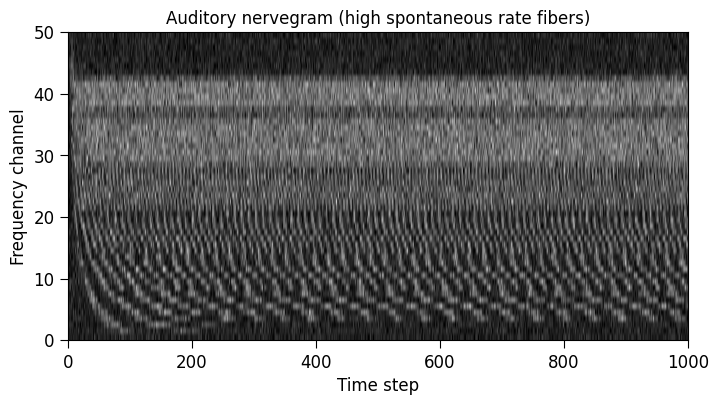

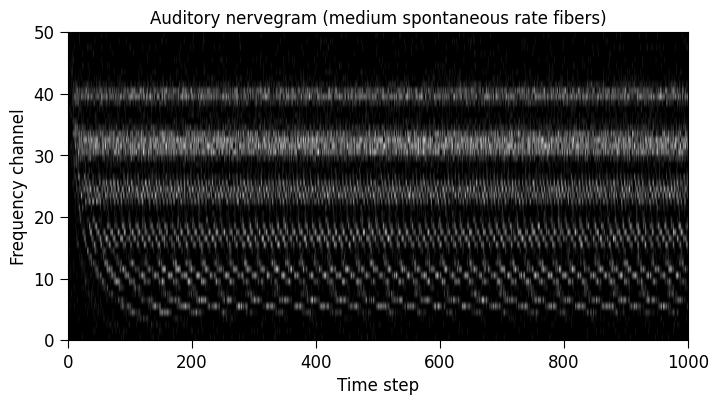

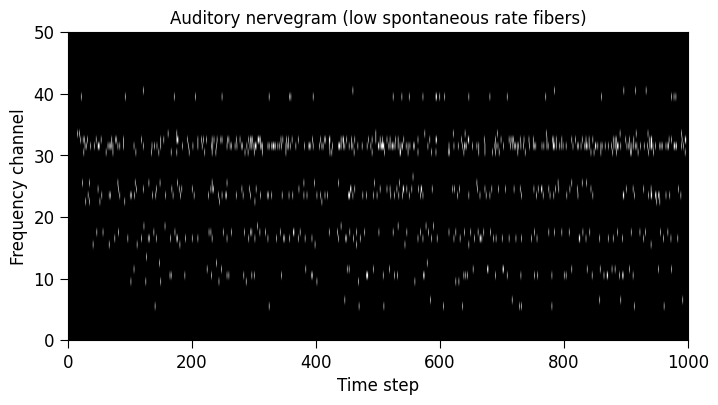

In [22]:
"""
Visualize a short excerpt of the nervegram.
"""
for itr, label in enumerate(["high", "medium", "low"]):
    img = nervegram[0, itr, :, :1000].detach().cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        extent=[0, img.shape[1], 0, img.shape[0]],
        cmap="gray",
    )
    ax = util.format_axes(
        ax,
        str_xlabel="Time step",
        str_ylabel="Frequency channel",
        str_title=f"Auditory nervegram ({label} spontaneous rate fibers)",
    )
    plt.show()
